In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import time
import torch
import torchvision
import torchvision.transforms as transforms

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device}.')

Using cuda.


In [3]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

def get_cifar10_loaders(batch_size=128, num_workers=2, root='../cifar_data'):
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

    train_set = torchvision.datasets.CIFAR10(root=root, train=True, transform=train_transform, download=True)
    test_set = torchvision.datasets.CIFAR10(root=root, train=False, transform=test_transform,  download=True)

    train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    test_iter = torch.utils.data.DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_iter, test_iter

In [4]:
class IntermediateBlock(torch.nn.Module):
    def __init__(self, input_channels, output_channels, num_convs=3, kernel_sizes=[3, 5, 7], use_residual=True):
        super().__init__()
        self.num_convs = num_convs
        self.use_residual = use_residual
        self.convs = torch.nn.ModuleList()

        for k in kernel_sizes:
            padding = k // 2
            self.convs.append(torch.nn.Sequential(
                torch.nn.Conv2d(input_channels, output_channels, kernel_size=k, padding=padding, bias=False),
                torch.nn.BatchNorm2d(output_channels),
                torch.nn.ReLU(inplace=True)))

        self.linear = torch.nn.Linear(input_channels, num_convs)
        self.out_bn = torch.nn.BatchNorm2d(output_channels)

        if use_residual:
            if input_channels != output_channels:
                self.intm_layer = torch.nn.Sequential(
                    torch.nn.Conv2d(input_channels, output_channels, kernel_size=1, bias=False),
                    torch.nn.BatchNorm2d(output_channels))
            else:
                self.intm_layer = torch.nn.Identity()

        self.final_relu = torch.nn.ReLU(inplace=True)

    def forward(self, x):
        m = x.mean(dim=(2, 3))
        a = torch.softmax(self.linear(m), dim=1)
        out = 0
        for l, conv in enumerate(self.convs):
            out += a[:, l].view(-1, 1, 1, 1) * conv(x)

        out = self.out_bn(out)

        if self.use_residual:
            out = out + self.intm_layer(x)

        return self.final_relu(out)


In [5]:
class Net(torch.nn.Module):
    def __init__(self, conv_arch, num_outputs=10, dropout_rate=0.3):
        super().__init__()

        input_channels = 3
        blocks = []

        for cfg in conv_arch:
            blocks.append(IntermediateBlock(
                input_channels = input_channels,
                output_channels = cfg['out_ch'],
                num_convs = cfg['num_convs'],
                kernel_sizes = cfg['kernel_sizes'],
                use_residual = cfg.get('use_residual', True)))

            blocks.append(torch.nn.MaxPool2d(kernel_size=2, stride=2))
            input_channels = cfg['out_ch']

        self.features = torch.nn.Sequential(*blocks)
        self.global_pool = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(input_channels, 512),
            torch.nn.BatchNorm1d(512),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(dropout_rate),
            torch.nn.Linear(512, 256),
            torch.nn.BatchNorm1d(256),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(dropout_rate * 0.5),
            torch.nn.Linear(256, num_outputs))

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

def init_weights(m):
    if isinstance(m, torch.nn.Conv2d):
        torch.nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)
    elif isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)
    elif isinstance(m,(torch.nn.BatchNorm2d, torch.nn.BatchNorm1d)):
        torch.nn.init.ones_(m.weight)
        torch.nn.init.zeros_(m.bias)

DEFAULT_CONV_ARCH = [
    {'out_ch':64,'num_convs': 3,'kernel_sizes':[3, 5, 7],'use_residual': True},
    {'out_ch':128,'num_convs': 3,'kernel_sizes':[3, 5, 7], 'use_residual': True},
    {'out_ch':256,'num_convs': 4,'kernel_sizes':[3, 3, 5, 7],'use_residual': True},
    {'out_ch':512,'num_convs': 4,'kernel_sizes':[3, 3, 5, 7],'use_residual': True}]


In [6]:
def correct(logits, y):
    return (logits.argmax(dim=1) == y).float().sum()

def evaluate_metric(model, data_iter, metric):
    c, n = 0., 0.
    for X, y in data_iter:
        X, y = X.to(device), y.to(device)
        with torch.no_grad():
            logits = model(X)
        c += metric(logits, y)
        n += len(y)
    return float(c / n)

def cutmix(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.shape
    cut_rat = (1 - lam) ** 0.5
    cut_h, cut_w = int(H * cut_rat), int(W * cut_rat)
    cx = torch.randint(W, (1,)).item()
    cy = torch.randint(H, (1,)).item()
    x1 = max(cx - cut_w // 2, 0);  x2 = min(cx + cut_w // 2, W)
    y1 = max(cy - cut_h // 2, 0);  y2 = min(cy + cut_h // 2, H)
    x_cut = x.clone()
    x_cut[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam_real = 1 - (x2 - x1) * (y2 - y1) / (H * W)
    return x_cut, y, y[idx], lam_real

def mixup(x, y, alpha=0.4):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def evaluate_with_tta(model, data_iter, n_aug=10):
    tta_aug = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip()])

    correct_n, total = 0., 0
    model.eval()

    for X, y in data_iter:
        X, y = X.to(device), y.to(device)
        probs = torch.zeros(X.size(0), 10, device=device)
        with torch.no_grad():
            for _ in range(n_aug):
                X_aug = torch.stack([tta_aug(img) for img in X])
                probs += torch.softmax(model(X_aug), dim=1)
        correct_n += (probs.argmax(dim=1) == y).float().sum()
        total += len(y)
    return float(correct_n / total) * 100


In [7]:
def train_model(num_epochs=250, batch_size=128, warmup_epochs=5,
                lr=0.1, momentum=0.9, weight_decay=5e-4,
                dropout_rate=0.3, conv_arch=None):

    if conv_arch is None:
        conv_arch = DEFAULT_CONV_ARCH

    train_iter, test_iter = get_cifar10_loaders(batch_size=batch_size)
    print(f'Train: {len(train_iter.dataset):,}  Test: {len(test_iter.dataset):,}')


    model = Net(conv_arch=conv_arch, num_outputs=10, dropout_rate=dropout_rate).to(device)
    model.apply(init_weights)
    print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


    loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr = lr,
        momentum = momentum,
        weight_decay = weight_decay,
        nesterov= True)

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
        return max(0.5 * (1.0 + torch.cos(torch.tensor(3.14159265 * progress)).item()), 1e-4)

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    losses, train_accs, test_accs = [], [], []
    best_test_acc, best_model_state = 0.0, None

    for epoch in range(num_epochs):
        current_lr = scheduler.get_last_lr()[0]
        start = time.perf_counter()
        model.train()
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            if torch.rand(1).item() < 0.5:
                X, y_a, y_b, lam = cutmix(X, y, alpha=1.0)
            else:
                X, y_a, y_b, lam = mixup(X, y, alpha=0.4)

            logits = model(X)
            l = lam * loss_fn(logits, y_a) + (1 - lam) * loss_fn(logits, y_b)

            optimizer.zero_grad()
            l.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            losses.append(float(l))

        scheduler.step()

        model.eval()
        with torch.no_grad():
            train_acc = evaluate_metric(model, train_iter, correct) * 100
            test_acc  = evaluate_metric(model, test_iter,  correct) * 100

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f'New best test: {best_test_acc:.2f}%')

        print(f'Epoch{epoch+1}/{num_epochs} lr={current_lr:.5f} Train: {train_acc:.2f}%  Test: {test_acc:.2f}%')

    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        final_test_acc = evaluate_metric(model, test_iter, correct) * 100
    final_test_acc_tta = evaluate_with_tta(model, test_iter, n_aug=10)

    print(f'Best test accuracy : {best_test_acc:.2f}%')
    print(f'Final test accuracy : {final_test_acc:.2f}%')
    print(f'Final test accuracy (TTAx10): {final_test_acc_tta:.2f}%')

    history = {
        'losses': losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'best_test_acc': best_test_acc,
        'final_test_acc': final_test_acc,
        'final_test_acc_tta': final_test_acc_tta}
    return model, history


In [8]:
model, history = train_model(num_epochs=250)

Train: 50,000  Test: 10,000
Parameters: 16,352,353


/tmp/ipykernel_5670/1684778427.py:54: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses.append(float(l))


New best test: 46.56%
Epoch1/250 lr=0.02000 Train: 44.65%  Test: 46.56%
New best test: 56.85%
Epoch2/250 lr=0.04000 Train: 54.18%  Test: 56.85%
New best test: 62.39%
Epoch3/250 lr=0.06000 Train: 61.22%  Test: 62.39%
New best test: 64.08%
Epoch4/250 lr=0.08000 Train: 62.68%  Test: 64.08%
New best test: 68.53%
Epoch5/250 lr=0.10000 Train: 67.22%  Test: 68.53%
New best test: 70.75%
Epoch6/250 lr=0.10000 Train: 71.15%  Test: 70.75%
New best test: 75.17%
Epoch7/250 lr=0.10000 Train: 74.15%  Test: 75.17%
New best test: 77.46%
Epoch8/250 lr=0.09998 Train: 76.02%  Test: 77.46%
Epoch9/250 lr=0.09996 Train: 74.56%  Test: 74.85%
Epoch10/250 lr=0.09993 Train: 74.55%  Test: 72.58%
Epoch11/250 lr=0.09990 Train: 76.70%  Test: 76.57%
Epoch12/250 lr=0.09985 Train: 75.80%  Test: 75.14%
New best test: 78.68%
Epoch13/250 lr=0.09980 Train: 78.93%  Test: 78.68%
Epoch14/250 lr=0.09974 Train: 78.37%  Test: 77.52%
Epoch15/250 lr=0.09967 Train: 75.90%  Test: 75.27%
Epoch16/250 lr=0.09959 Train: 73.98%  Test: 73

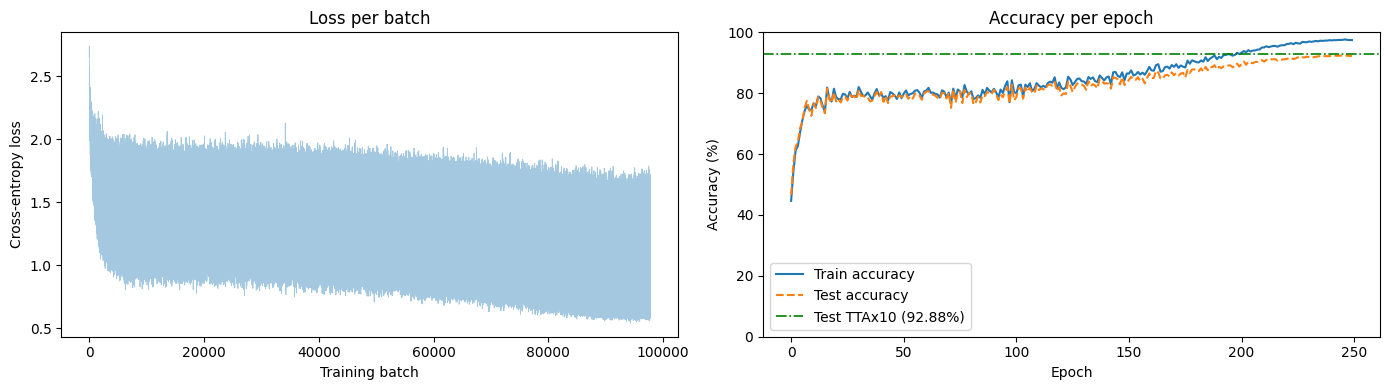

In [9]:
losses = history['losses']
train_accs = history['train_accs']
test_accs = history['test_accs']
final_test_acc = history['final_test_acc']
final_test_acc_tta = history['final_test_acc_tta']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses, alpha=0.4, linewidth=0.6)
axes[0].set_xlabel('Training batch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Loss per batch')

axes[1].plot(train_accs, label='Train accuracy')
axes[1].plot(test_accs,  label='Test accuracy', linestyle='--')
axes[1].axhline(y=final_test_acc_tta, color='green', linestyle='-.',
                linewidth=1.2,label=f'Test TTAx10 ({final_test_acc_tta:.2f}%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy per epoch')
axes[1].legend()
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()
